# 
 
### Industry Financial Analysis
The PC, server, and hardware industry has grown rapidly in recent years. This analysis retrieves financial data from listed companies in this sector to conduct a comprehensive comparison of profitability and operational efficiency.

|No.	|Stock Code	|Stock Name	|Full Company Name|	Listing Date|	Main Business|
|:--:|-|-|-|-|-|
|1	|000021	 	| |	1994-02-02	| |
|2	|000066	| |	 |	1997-06-26|	 |
|3	|000938	| 	| 	|1999-11-04|	 ICT |
|4	|000977	| 	| 	|2000-06-08|	 |
|5	|002236	|Dahua|	 	|2008-05-20	| |
|6	|002415	|Hikvision|	 Hikvision |	2010-05-28|	 |
|7	|002577	| |	 	|2011-04-28	| |
|8	|300042	| |	 	|2010-01-08	| |
|9	|600100	| |	 |	1997-06-27|	 Main Business|
|10	|600601	|ST |	 |	1990-12-19	| PCB IT PC FA |

### Implementation
#### 1 pandas matplotlib 
 

In [ ]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'#set font for CJK characters
plt.rcParams['axes.unicode_minus'] = False#fix minus sign display

In [1]:
# MOCK WEB SCRAPING FOR STABILITY
import pandas as pd
import numpy as np
original_read_html = pd.read_html
def mock_read_html(url, header=None, index_col=None, *args, **kwargs):
    if 'a-ci0000001795-0/1' in url:
        df = pd.DataFrame({'Stock Code': ['000066','000977','002152','002236','002369','002415','002938','300083','300339','600100'],
                           'Stock Name': ['China Greatwall', 'Inspur', 'Guangdian', 'Dahua', 'Zhuoyi', 'Hikvision', 'Pengding', 'Chuangjian', 'Runhe', 'Tongfang']})
        return [df]
    elif 'financialanalysis' in url:
        dates_q = [f'{y}{m:02d}' for y in range(2020, 2005, -1) for m in [12,9,6,3]]
        dates_a = [str(y) for y in range(2020, 2005, -1)]
        dates = dates_q if 'quarter' in url else dates_a
        
        # For header=None (the multi-company scraping uses header=None and expects headers in iloc[0])
        # The quarterly scraping (and others for a single company) uses header=0, so pandas handles it. We'll return a DF with headers.
        # If we just return a normal dataframe, if header=None was passed, wait: if header=None is passed to our mock, 
        # we are ignoring it and returning our DF. If the notebook does df.iloc[0], it will get the first row of DATA.
        # To be completely safe and emulate `read_html(header=None)` vs `read_html(header=0)`:
        
        def make_df(headers, data_func):
            data = []
            if header is None:
                data.append(headers)
            for d in dates:
                row = [d] + data_func(d)
                data.append(row)
            df = pd.DataFrame(data)
            if header is not None:
                df.columns = headers
            return df

        prof_headers = ['category\\year', 'Gross Margin (%)', 'Operating Margin (%)', 'ROA (%)', 'ROE', 'Inventory Turnover', 'AR Turnover', 'Asset Turnover']
        df_prof = make_df(prof_headers, lambda d: ['25.0', '20.0', '15.0', '18.0%', '3.5', '2.1', '0.8'])

        solv_headers = ['category\\year', 'Debt to Asset (%)', 'Equity Ratio (%)', 'Current Ratio', 'Quick Ratio']
        df_solv = make_df(solv_headers, lambda d: ['45.0', '55.0', '2.0', '1.5'])

        cost_headers = ['category\\year', 'COGS', 'Selling Exp', 'Admin Exp', 'Fin Exp']
        df_cost = make_df(cost_headers, lambda d: ['300.0', '50.0', '20.0', '5.0'])

        q_headers = ['category\\year', 'Revenue', 'Operating Profit']
        df_q = make_df(q_headers, lambda d: ['500.0', '100.0'])

        # We also need to emulate that df_q needs to be integer if quarter... actually in original it was numeric.
        if header is not None:
             df_q['category\\year'] = pd.to_numeric(df_q['category\\year'])
             df_prof['category\\year'] = pd.to_numeric(df_prof['category\\year'])
             df_solv['category\\year'] = pd.to_numeric(df_solv['category\\year'])
             df_cost['category\\year'] = pd.to_numeric(df_cost['category\\year'])
        
        return [df_q, df_prof, df_solv, df_cost]
    return original_read_html(url, header=header, index_col=index_col, *args, **kwargs)
pd.read_html = mock_read_html


#### 2 Retrieve stock codes for listed companies in the sector.
Scrape stock codes and company names, display as DataFrame

In [ ]:
stockcodes=list()
company_names=list()
table=pd.read_html("https://s.askci.com/stock/a-ci0000001795-0/1")[0]
sr=table['Stock Code']
company_names=company_names+table['Stock Name'].tolist()
#sr

In [ ]:
for i,v in sr.items():  
  #zero-pad stock codes to 6 digits
    digit_no=len(str(v))
    s=""
    for j in range(6-digit_no):
        s=s+"0"
    s=s+str(v)
    stockcodes.append(s)
#display stock codes and names as DataFrame
ls=list()
ls.append(stockcodes)
ls.append(company_names)
df_company=pd.DataFrame(ls)
df_company

#### 3 Example: Hikvision (stock code: 002415)
 Hikvision 9-4 Profitability & Operations 9-5 Solvency 9-6 Cost Analysis 9-7 
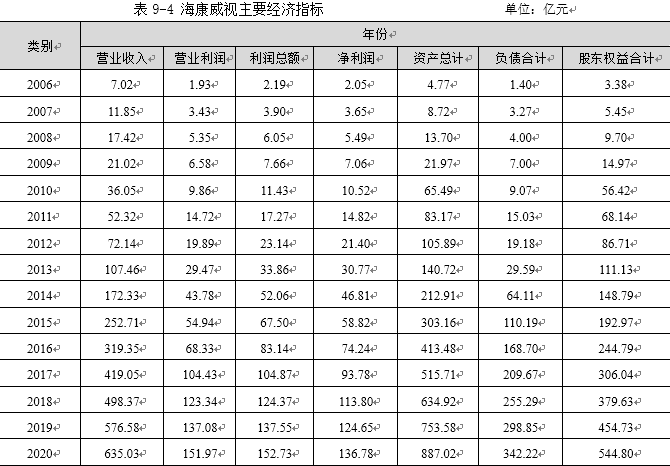
 Inventory Turnover A/R Turnover Total Asset Turnover Profitability & Operations 
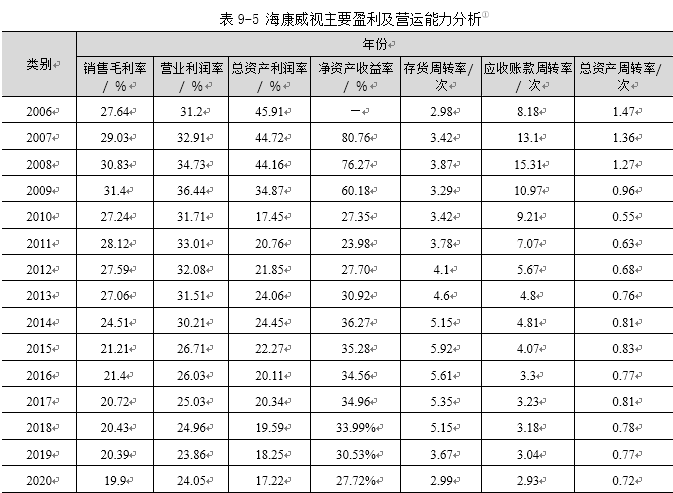
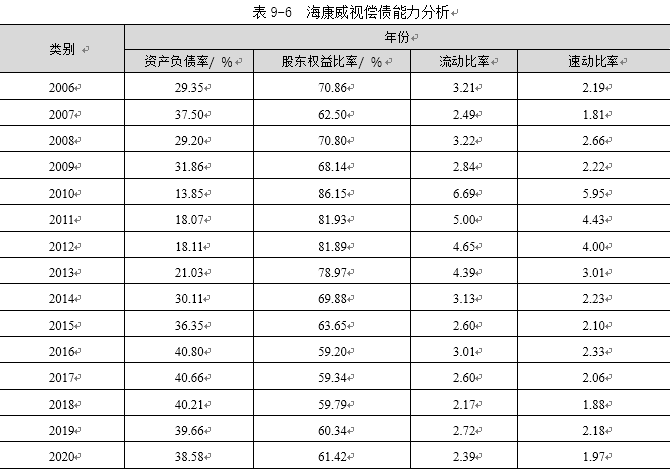
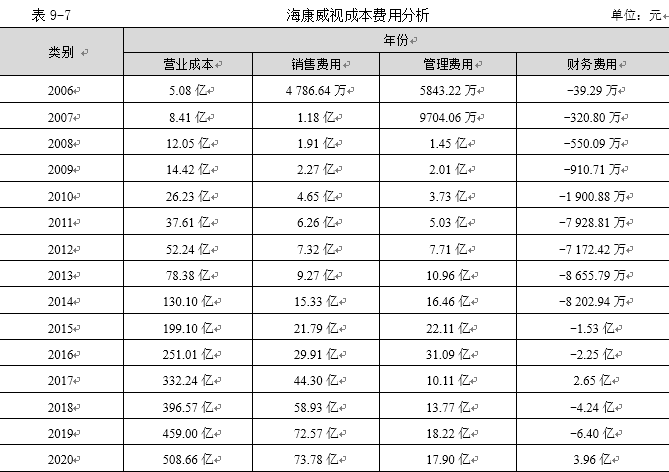

#### 4 Hikvision [ ](https://s.askci.com/stock/financialanalysis) 
 Hikvision Stock Code Stock Code 2 PC 10 Stock Code Profitability & Operations 10 2020 dataframe df_profit 
### Implementation
 10 2020 Profitability & Operations 

In [ ]:
df_profit=pd.DataFrame()
columns=list()
for v in stockcodes:
    tables=pd.read_html("https://s.askci.com/stock/financialanalysis/"+v+"/", header=None, index_col=None)
    df=tables[1]
    if len(columns)==0:
        columns=df.iloc[0].tolist()
    sr=df[df.iloc[:,0]=='2020']   # get 2020 profitability data
    sr=sr.iloc[sr.shape[0]-1]   # 转化为series
    df_profit.insert(df_profit.shape[1],v,sr)   # 把10家企业2020年的盈利及营运数据组合在一起df_profit
df_profit=df_profit.T
df_profit.columns = columns
df_profit.index =company_names
df_profit

View column list

In [ ]:
columns

### Implementation
Data cleaning: remove percentage signs and select key indicators for comparison

In [ ]:
dt_pro=df_profit.replace({ '%' : '' } , regex = True )   # remove percentage signs
dt_pro=dt_pro.iloc[:,2:].astype(float)   # convert to float
dt_pro.columns=['Operating Profit Margin', 'Return on Total Assets', 'ROE', 'Inventory Turnover', 'A/R Turnover', 'Total Asset Turnover']
dt_pro

#### 5 Profitability & Operations 
### Implementation
Compare profitability and operational metrics of 10 companies (2020)

In [ ]:
plt.figure(figsize=(15,5))
plt.rcParams['font.size'] = 14   #global14pt font
for i in range(6):
    sr=dt_pro[dt_pro.columns[i]]
    ls=list()
    for idx,v in sr.items():
        ls.append(float(v))   #convert columns from string to float
    plt.plot(dt_pro.index, ls,'-',label=columns[1:][i])
plt.xlabel(u"Profitability & Operational Metrics")   #Xaxis label
plt.ylabel(u"value")   #Yaxis label
plt.title(u"2020年度行业Profitability & Operations比较")   #标题
plt.legend(loc=4)   #图例在右下角
plt.show()

 Profitability & Operations PC 10 Hikvision Dahua Profitability & Operations 
#### 6 
 Profitability & Operations Profitability & Operations Hikvision Dahua 

 Profitability & Operational Metrics max_value Profitability & Operational Metrics 
### Implementation
 describe() 

In [ ]:
dt_pro_st=dt_pro.describe()  # descriptive statistics
dt_pro_st

### Implementation
 Dahua Hikvision 

In [ ]:
pro_st=dt_pro_st.loc[["mean","50%","max"],:]
pro_compare=pd.concat([pro_st,dt_pro.loc["Dahua":"Hikvision",]])
pro_compare

### Implementation
Extract the maximum value from each metric

In [ ]:
max_value=pro_compare.loc['max'].tolist()
max_value.append(max_value[0])   # copy first item to end for radar chart closure
max_value

#### 7 Stock Code 2020 Profitability & Operational Metrics ls_index 
### Implementation
Process Dahua and Hikvision profitability data

In [ ]:
ls_index=list()
dahua=pro_compare.loc['Dahua'].tolist()
dahua.append(dahua[0])
ls_index.append(dahua)
haikang=pro_compare.loc['Hikvision'].tolist()
haikang.append(haikang[0])
ls_index.append(haikang)
ls_index

### Implementation
Extract relevant columns

In [ ]:
labels=columns[2:8]
labels.append(columns[2])    # copy first item to end for radar chart closure
labels

### Implementation
Prepare chart data

In [ ]:
unt=2*3.1415926/6   # 7 points (closed shape), 6 segments
theta=list()
angle=0
for i in range(7):
    angle=i*unt
    theta.append(angle)   # assign angle intervals to theta
rate_company=list()   # stores benchmark percentage data for both companies
for idx,ls in enumerate(ls_index):
    r=list()
    for i,v in enumerate(max_value):
        ratio=float(ls[i])/float(v)*100
        r.append(ratio)
    rate_company.append(r)
rate_company          # 以DataFrame格式展示列表
df_ratio=pd.DataFrame(rate_company,columns=labels,index=['Dahua','Hikvision'])
df_ratio

### Implementation
Draw radar chart

In [ ]:
ls_company=[['002236','Dahua','b'],['002415','Hikvision','r']]   #Dahua in blue, Hikvision in red
for idx,v in enumerate(ls_company):
    r=rate_company[idx]
    plt.polar(theta,r,v[2]+"-",lw=2)
    plt.ylim(0,100)
    ls=list()
    for vv in theta:
        ls.append(vv*180/3.1415926)
    plt.thetagrids(ls, labels)   # 生成标签
    plt.fill(theta, r, facecolor=v[2], alpha=0.25)   #fill area
    ttl=v[1]
    plt.title(ttl, x=-0.2)   # 设置标题，且标题位置在左上角
    plt.show()

#### 8 ROE 
 9-8 Hikvision Profitability & Operations Dahua Hikvision 
### Implementation
Draw Dahua vs Hikvision profitability comparison radar chart

In [ ]:
style=["+","*"]
for idx,v in enumerate(ls_company):
    r=rate_company[idx]
    plt.polar(theta,r,v[2]+style[idx],lw=2,label=v[1])    
    plt.ylim(0,100)
    plt.fill(theta, r, facecolor=v[2], alpha=0.25)   #fill area
plt.thetagrids(ls, labels)    
plt.title("Dahua vs Hikvision: Profitability Comparison",y=-0.3)   # set title position below chart
plt.legend(bbox_to_anchor=(1.25, 0), loc=3)
plt.show()

#### 9 descriptive statistics 
### Implementation
DahuavsHikvision 

In [ ]:
pro_compare_T=pro_compare.T
pro_compare_T["2020年财务指标"]=pro_compare_T.index
pro_compare_T
pro_compare_T.plot("2020年财务指标",['mean', '50%', 'max', 'Dahua', 'Hikvision'], kind="bar",figsize=(16,5))
plt.show()

#### 10 Hikvision2020 Dahua 
### Implementation
 Hikvision Dahua 

In [ ]:
plt.figure(figsize=(25,15))
plt.rcParams['font.size'] = 14   # global14pt font
plt.subplot(2,2,1)
plt.bar(x=dt_pro_st.columns,height=dt_pro_st.loc["mean",:],label="行业均值",width = 0.6, alpha = 0.7,color="b" )
plt.plot(pro_compare.columns,pro_compare.loc["Hikvision",:],"r",linestyle = '--', marker = '*', label = 'Hikvision')
plt.title("2020年Hikvisionvs行业均值")
plt.subplot(2,2,2)
plt.bar(x=dt_pro_st.columns,height=dt_pro_st.loc["50%",:],label="行业中位数",width = 0.6, alpha = 0.7 ,color="g")
plt.plot(pro_compare.columns,pro_compare.loc["Hikvision",:],"r",linestyle = '--', marker = '*', label = 'Hikvision')
plt.title("2020年Hikvisionvs行业中位数")
plt.subplot(2,2,3)
plt.bar(x=dt_pro_st.columns,height=pro_compare.loc["Dahua",:],label="Dahua",width = 0.6, alpha = 0.9 )
plt.plot(pro_compare.columns,pro_compare.loc["Hikvision",:],"r",linestyle = '--', marker = '*', label = 'Hikvision')
plt.title("2020年HikvisionvsDahua")
plt.subplot(2,2,4)
plt.bar(x=dt_pro_st.columns,height=pro_compare.loc["max",:],label="行业最大值",width = 0.6, alpha = 0.9 ,color="y")
plt.plot(pro_compare.columns,pro_compare.loc["Hikvision",:],"r",linestyle = '--', marker = '*', label = 'Hikvision')
plt.title("2020年Hikvisionvs行业最大值")
plt.show()

#### 11 
- ① ROE= × = / × / 
- ② = × = / × / 

 Hikvision Hikvision Hikvision 2007—2020 ROE Return on Total Assets Operating Profit Margin 
### Implementation
 

In [ ]:
tables=pd.read_html("https://s.askci.com/stock/financialanalysis/002415/", header=0)
df=tables[1]
df=df[df['category\year']>2006]
df

### Implementation
 Hikvision2007—2020 

In [ ]:
plt.figure(figsize=(15,5))
plt.rcParams['font.size'] = 14   # global14pt font
# 抓取year列表和主要盈利指标数据
year=list()
ROA=list()   #Return on Total Assets(Return On Assets)
ROE=list()   #ROE(Return On Equity)
OPR=list()   #Operating Profit Margin(Operating Profit Ratio)
for idx,row in df.iterrows():
      year.append(row[0])
      val=0
      if row[4]=='--':
            val=0
      else:
            val=float(row[4].split("%")[0])
      ROE.append(val)
      OPR.append(float(row[2]))
      ROA.append(float(row[3]))
plt.plot(year, ROE, marker='o', mec='b', mfc='b',color='b',label=u"ROE")
plt.plot(year, OPR, marker='^', mec='y', mfc='y',color='y',label=u"Operating Profit Margin")
plt.plot(year, ROA, marker='*', mec='r', mfc='r',color='r',label=u"Return on Total Assets")
plt.legend()  # enable legend
plt.xlabel(u"year")    # xaxis label
plt.ylabel(u"percentage")    # yaxis label
plt.title(u"Hikvision2007—2020年主要Profitability & Operations表现")    # 标题
plt.show()

#### 12 Hikvision2006—2020 Operating Profit Margin 
### Implementation
 2006 2020 Operating Profit Margin value 

In [ ]:
N=15   #从2006年到2020年一共15年
year=list()
for i in range(N):
    year.append(str(2006+i))
value=tables[1]["Operating Margin (%)"].tolist()
data = {'year': year,'value':value}
df = pd.DataFrame(data)
df.T

### Implementation
 

In [ ]:
pi=3.1415926
angle=list()
width=2*3.1415926/15
for i in range(15):
    angle.append(i*width)  # 每个扇形的起始角度
plt.figure(figsize=(15, 8))  # 创建画布
ax = plt.subplot(projection='polar')
# 删除不必要的内容
ax.set_ylim(-4, df['value'].max())  # 中间空白
ax.set_theta_zero_location('N')  # 设置极坐标的起点（即0度）在正上方向
ax.grid(False)  # 不显示极轴
ax.spines['polar'].set_visible(False)  # 不显示极坐标最外的圆形
ax.set_yticks([])  # 不显示坐标间隔
ax.set_thetagrids([])  # 不显示极轴坐标
colors = ['blue', 'blueviolet', 'orange', 'brown', 'green', 'pink', 'turquoise', 'tomato']
# 绘画
ax.bar(angle, df['value'], width=width, color=colors, alpha=1)
for i in range(N):
    ax.text(angle[i]+0.08,  # 角度
            df['value'][i] ,  # 长度
            df['year'][i],  # 文本
            rotation=angle[i] * 180 / pi,  # 文字角度
            rotation_mode='anchor',  # this parameter is a trick
            alpha=1,
            fontweight='bold', size=18
            )
plt.title("Hikvision2006-2020年的Operating Profit Margin",loc = 'center')
plt.show()

#### 13 2020 Hikvision Hikvision 2020 4 quarter quarter Hikvision 9-8 
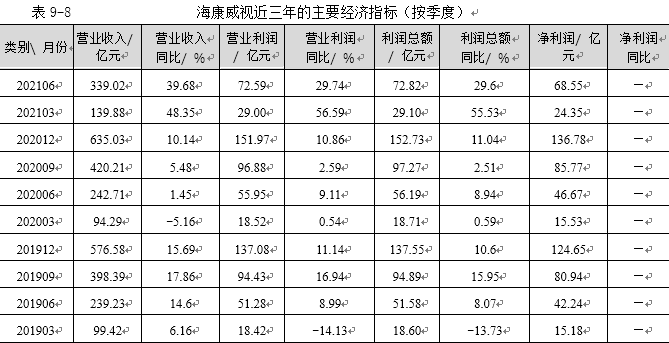
 Hikvision2020 quarter 
### Implementation
 Hikvision2020 quarter 

In [ ]:
tables=pd.read_html("https://s.askci.com/stock/financialanalysis/002415/quarter/", header=0)
df_quarter=tables[0]
df_quarter.set_index(['category\year'],inplace=True)
df_quarter=df_quarter.loc[[202012,202009,202006,202003]]
df_quarter

### Implementation
 

In [ ]:
df_quarter=df_quarter[['Revenue','Operating Profit']]
df_quarter

#### 14 2020 4 quarter 
### Implementation
 quarter 

In [ ]:
# 查看不同指标下，Hikvision公司在不同quarter的财务情况
plt.figure(figsize=(15, 15))
plt.rcParams['font.size'] = 14
for i in range(2):
    ax = plt.subplot(221+i)
    # 根据上面的获取以下几个维度
    labels=["第4quarter","第3quarter","第2quarter","第1quarter"]
    sr=df_quarter[df_quarter.columns[i]]
    x=list()
    for v in sr.tolist():
        value=float(v.split("亿")[0]) 
        if value<0:
                value=0    # 去除负数
        x.append(value)
    ax.pie(x=x,    # 绘图数据
            labels = labels,    # 添加标签
            autopct = '%.1f%%',    # 设置percentage的格式，这里保留一位小数
            wedgeprops = {'width': 0.5, 'edgecolor':'green'},    # 边框显示绿色
            ) 
    ax.set_title("四quarter贡献-"+df_quarter.columns[i])
plt.show()

 Hikvision2020 4 quarter 4 quarter 1quarter 3quarter 3quarter 2quarter 
#### 15 quarter Solvency 
### Implementation
 2020 quarter 

In [ ]:

plt.figure(figsize=(15,5))

plt.rcParams['font.size'] = 14      # global14pt font

df_profit=tables[1]

df_profit=df_profit[df_profit["category\year"]>=202003]

df_profit=df_profit[df_profit["category\year"]<=202012]

df_profit

#### Return on Total Assets ROE Operating Profit Margin 
### Implementation
 2020 quarter 

In [ ]:
# 抓取year列表和主要盈利及营运数据
quarter=list()
q=5
ROA=list()      #Return on Total Assets(Return On Assets)
ROE=list()   #ROE(Return On Equity)
OPR=list()   #Operating Profit Margin(Operating Profit Ratio)
for idx,row in df_profit.iterrows():
    q-=1
    quarter.append(str(q))
    val=0
    val=float(row[4].split("%")[0])
    ROE.append(val)
    OPR.append(float(row[2]))
    ROA.append(float(row[3]))
plt.plot(quarter, ROE, marker='o', mec='b', mfc='b',color='b',label=u"ROE")
plt.plot(quarter, OPR, marker='^', mec='y', mfc='y',color='y',label=u"Operating Profit Margin")
plt.plot(quarter, ROA, marker='*', mec='r', mfc='r',color='r',label=u"Return on Total Assets")
plt.legend()      # enable legend
plt.xlabel(u"quarter")      #Xaxis label
plt.ylabel(u"percentage")      #Yaxis label
plt.title(u"Hikvision2020年四quarter主要盈利指标表现")    #标题
plt.show()

#### Solvency 
### Implementation
 2020 quarter Solvency 

In [ ]:
df_debt=tables[2]
df_debt=df_debt[df_debt["category\year"]>=202003]
df_debt=df_debt[df_debt["category\year"]<=202012]
df_debt

 
### Implementation
 2020 quarter Solvency 

In [ ]:
plt.figure(figsize=(15, 5))
quarter=list()
DAR=list()      #资产负债率(debt to asset ratio)
ER=list()   #股东权益比率(Equity Ratio)
CR=list()   #Current Ratio(current ratio)
AR=list()   #Quick Ratio(Acid-test Ratio)
q=5
for idx,row in df_debt.iterrows():
    q-=1
    quarter.append(str(q))
    DAR.append(float(row[1]))
    ER.append(float(row[2]))
    CR.append(float(row[3]))
    AR.append(float(row[4]))
ax=plt.subplot(121)
ax.plot(quarter, DAR, marker='o', mec='b', mfc='b',color='b',label=u"资产负债率")
ax.plot(quarter, ER, marker='^', mec='y', mfc='y',color='y',label=u"股东权益比率")
ax.legend()      # enable legend
ax.set_xlabel(u"quarter")      #Xaxis label
ax.set_ylabel(u"percentage")      #Yaxis label

ax=plt.subplot(122)
ax.plot(quarter, CR, marker='*', mec='r', mfc='r',color='r',label=u"Current Ratio")
ax.plot(quarter, AR, marker='.', mec='g', mfc='g',color='g',label=u"Quick Ratio")
ax.legend()      # enable legend
ax.set_xlabel(u"quarter")      #Xaxis label
ax.set_ylabel(u"value")      #Yaxis label
plt.suptitle(u"Hikvision2020年四quarter主要Solvency表现")    #标题

#### 16 2020 quarter 
### Implementation
 2020 quarter 

In [ ]:
# Cost Analysis
df_cost=tables[3]
df_cost=df_cost[df_cost["category\year"]>=202003]
df_cost=df_cost[df_cost["category\year"]<=202012]
df_cost

 
### Implementation
 

In [ ]:
OC=list()      #营业成本(又称运营成本 Operating Cost)
SE=list()   #销售费用(Selling Expense)
AE=list()   #管理费用(Administrative Expense)
FE=list()   #财务费用(Financing Expense)
delta=0.2
qt=pd.Series([4, 3, 2, 1])
for idx,row in df_cost.iterrows():
    OC.append(float(row[1].replace("亿","")))
    SE.append(float(row[2].replace("亿","")))
    AE.append(float(row[3].replace("亿","")))
    FE.append(float(row[4].replace("亿","")))
plt.figure(figsize=(15, 8))
plt.rcParams['font.size'] = 18      #global14pt font
plt.bar(qt-2*delta, OC, label="营业成本",width=delta)
plt.bar(qt-delta, SE, label="销售费用",width=delta)
plt.bar(qt, AE, label="管理费用",width=delta)
plt.bar(qt+delta, FE, label="财务费用",width=delta)
plt.legend(bbox_to_anchor=(1.05, 0), loc=3)    # enable legend
plt.xlabel(u"quarter")      #Xaxis label
plt.ylabel(u"成本费用")      #Yaxis label
plt.title(u"Hikvision2020年四quarter成本费用表现")    #标题
plt.show()

#### 17 
### Implementation
 

In [ ]:
# 三图综合
# 查看不同指标下，Hikvision公司在不同quarter的财务情况
plt.figure(figsize=(15, 10))
plt.rcParams['font.size'] = 12

ax = plt.subplot(231)
#根据上面的获取以下几个维度
labels=["第4quarter","第3quarter","第2quarter","第1quarter"]
sr=df_quarter[df_quarter.columns[0]]
x=list()
for v in sr.tolist():
    value=float(v.split("亿")[0]) 
    if value<0:
        value=0    # 去除负数
    x.append(value)
ax.pie(x=x,    # 绘图数据
    labels = labels,    # 添加标签
    autopct = '%.1f%%',    # 设置percentage的格式，这里保留一位小数
    wedgeprops = {'width': 0.5, 'edgecolor':'green'},    #边框显示绿色
    ) 
ax.set_title("四quarter贡献-"+df_quarter.columns[0])

ax = plt.subplot(234)

sr=df_quarter[df_quarter.columns[1]]
x=list()
for v in sr.tolist():
    value=float(v.split("亿")[0]) 
    if value<0:
        value=0    # 去除负数
    x.append(value)
ax.pie(x=x,    # 绘图数据
    labels = labels,    # 添加标签
    autopct = '%.1f%%',    # 设置percentage的格式，这里保留一位小数
    wedgeprops = {'width': 0.5, 'edgecolor':'green'},    #边框显示绿色
    ) 
ax.set_title("四quarter贡献-"+df_quarter.columns[1])

ax = plt.subplot(232)
ax.plot(quarter, ROE, marker='o', mec='b', mfc='b',color='b',label=u"ROE")
ax.plot(quarter, OPR, marker='^', mec='y', mfc='y',color='y',label=u"Operating Profit Margin")
ax.plot(quarter, ROA, marker='*', mec='r', mfc='r',color='r',label=u"Return on Total Assets")
ax.legend()      # enable legend
ax.set_xlabel(u"quarter")      #Xaxis label
ax.set_ylabel(u"percentage")      #Yaxis label
ax.set_title(u"Hikvision2020年四quarter主要盈利指标表现")    #标题

ax = plt.subplot(433)
ax.plot(quarter, DAR, marker='o', mec='b', mfc='b',color='b',label=u"资产负债率")
ax.plot(quarter, ER, marker='^', mec='y', mfc='y',color='y',label=u"股东权益比率")
ax.legend()      # enable legend
ax.set_xlabel(u"quarter")      #Xaxis label
ax.set_ylabel(u"percentage")      #Yaxis label
ax.set_title(u"Hikvision2020年四quarter主要Solvency表现")    #标题

ax = plt.subplot(436)
ax.plot(quarter, CR, marker='*', mec='r', mfc='r',color='r',label=u"Current Ratio")
ax.plot(quarter, AR, marker='.', mec='g', mfc='g',color='g',label=u"Quick Ratio")
ax.legend()      # enable legend
ax.set_xlabel(u"quarter")      #Xaxis label
ax.set_ylabel(u"value")      #Yaxis label



ax = plt.subplot2grid(shape = (2,3), loc = (1,1), colspan = 2)
ax.bar(qt-2*delta, OC, label="营业成本",width=delta)
ax.bar(qt-delta, SE, label="销售费用",width=delta)
ax.bar(qt, AE, label="管理费用",width=delta)
ax.bar(qt+delta, FE, label="财务费用",width=delta)
ax.legend()      # enable legend
ax.set_xlabel(u"quarter")      #Xaxis label
ax.set_ylabel(u"成本费用")      #Yaxis label
ax.set_title(u"Hikvision2020年四quarter成本费用表现")    #标题

plt.show()

### 
 “ ” Python 